In [1]:
import pandas as pd
import numpy as np 
import re 
from pathlib import Path


In [4]:
search_locations = [
    Path.cwd(),
    Path.cwd() / "Data",
    Path("/Data"),
    Path("/mnt/data"),
]

candidates = []
for location in search_locations:
    if location.exists():
        candidates.extend(location.rglob("ITA Data CY 2016.csv"))

if not candidates:
    for location in search_locations:
        if location.exists():
            candidates.extend(location.rglob("*.csv"))

if not candidates:
    raise FileNotFoundError(
        f"No CSV file was found. Current working directory: {Path.cwd()}"
    )

In [6]:
input_files=candidates[0]
df=pd.read_csv(input_files,low_memory=False)

# remove completed empty columns
empty_columns=[c for c in df.columns if df[c].isna().all()]
df=df.drop(columns=empty_columns)

# remove dublicated row
duplicate_count=int(df.duplicated().sum())
df=df.drop_duplicates().copy()

# clean columns names
df.columns = [
    re.sub(r"[^a-z0-9]+", "_", str(c).strip().lower()).strip("_")
    for c in df.columns
]
# clean text columns
# stopwords/punctuation are remove only for text columns.
# numeric/id columns are not treated as text

stop_words={
    "a","an","the","and","or","but","if","then","than","so","because",
    "as","of","at","by","for","from","in","into","on","to","with","without",
    "is","are","was","were","be","been","being","this","that","these","those",
    "it","its","he","she","they","them","we","you","your","our","their",
    "i","me","my","his","her","their","have","has","had","do","does","did"
}
text_columns=df.select_dtypes(include=["object","string"]).columns.tolist()

def clean_text(value):
    if pd.isna(value):
        return ""
    text=str(value).lower().strip()
    text=re.sub(r"[^a-z0-9\s]"," ",text)
    words=[w for w in text.split() if w not in stop_words]
    return "".join(words)

for col in text_columns:
    df[col]=df[col].map(clean_text)

# convert the numeric columns
numeric_columns=[
        "annual_average_employees",
    "total_hours_worked",
    "no_injuries_illnesses",
    "total_deaths",
    "total_dafw_cases",
    "total_djtr_cases",
    "total_other_cases",
    "total_dafw_days",
    "total_djtr_days",
    "total_injuries",
    "total_poisonings",
    "total_respiratory_conditions",
    "total_skin_disorders",
    "total_hearing_loss",
    "total_other_illnesses",
    "year_filing_for"
]
numeric_columns=[c for c in numeric_columns if c in df.columns]

for col in numeric_columns:
    df[col]=pd.to_numeric(df[col],errors="coerce")

    




In [7]:
negative_counts={}
for col in numeric_columns:
    count=int((df[col]<0).sum())
    negative_counts[col]=count
    if count:
        df.loc[df[col]<0,col]=np.nan

 
# 7. Null-value report BEFORE filling
null_before=df.isna().sum()
null_before = null_before[null_before > 0].sort_values(ascending=False)

# Fill numeric nulls with median
for col in numeric_columns:
    if df[col].isna().any():
        median_value = df[col].median()
        if pd.notna(median_value):
            df[col] = df[col].fillna(median_value)
        else:
            df[col] = df[col].fillna(0)

# Fill text nulls with "unknown"
for col in text_columns:
    if df[col].isna().any():
        df[col] = df[col].fillna("unknown")


In [9]:
print("numerical columns")
print(numeric_columns)

numerical columns
['annual_average_employees', 'total_hours_worked', 'no_injuries_illnesses', 'total_deaths', 'total_dafw_cases', 'total_djtr_cases', 'total_other_cases', 'total_dafw_days', 'total_djtr_days', 'total_injuries', 'total_poisonings', 'total_respiratory_conditions', 'total_skin_disorders', 'total_hearing_loss', 'total_other_illnesses', 'year_filing_for']


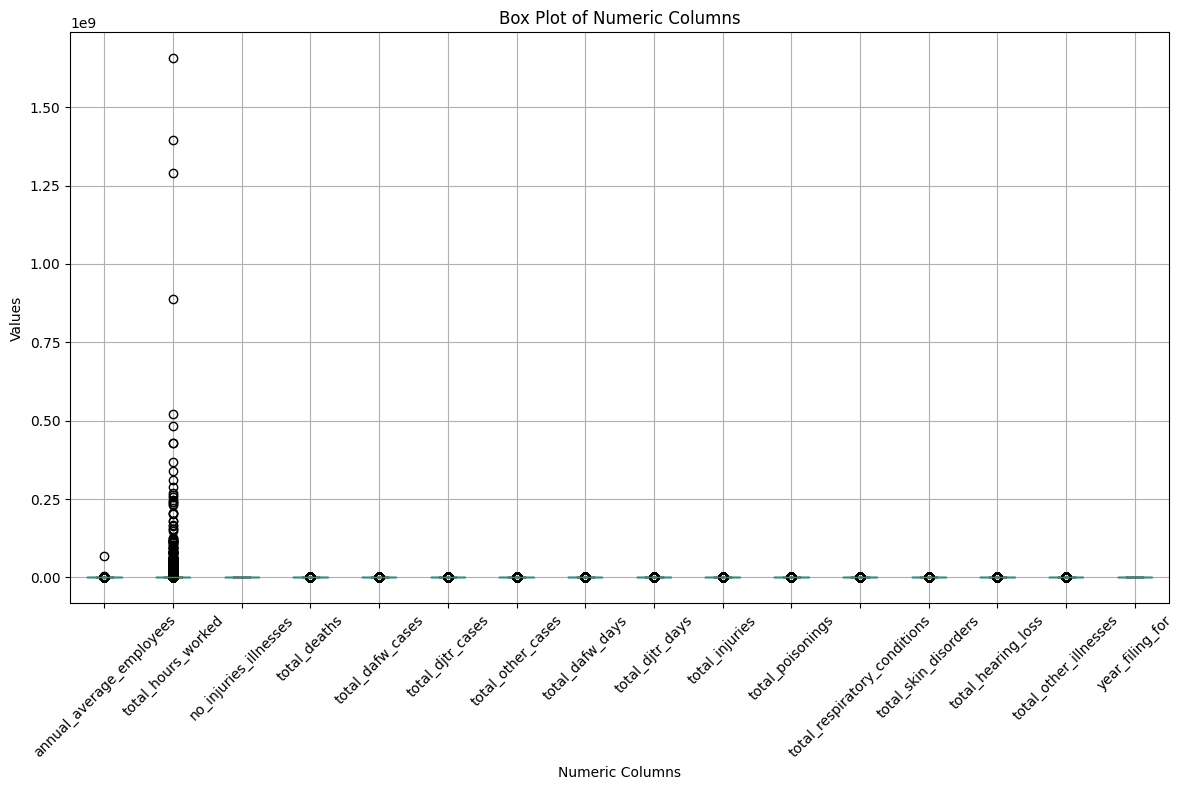

In [11]:
# drow boxplot
import matplotlib.pyplot as plt
df[numeric_columns].boxplot(figsize=(12,8))
plt.title("Box Plot of Numeric Columns")
plt.xlabel("Numeric Columns")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
outlier_report = []

for col in numeric_columns:
    s = df[col].dropna()
    if len(s) < 4:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        count = 0
        lower = q1
        upper = q3
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = int(((s < lower) | (s > upper)).sum())

    outlier_report.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count,
        "outlier_percent": round(count / len(s) * 100, 2)
    })

outliers = pd.DataFrame(outlier_report).sort_values(
    "outlier_count", ascending=False
)

In [13]:
# -----------------------------
# 9. Remove duplicate/empty rows created by text cleaning
# -----------------------------
df = df.drop_duplicates().copy()

In [14]:
# 10. Create prototype target
#     IMPORTANT: this is NOT true SIF potential.
# -----------------------------
if "total_deaths" in df.columns:
    df["fatality_indicator"] = (df["total_deaths"] > 0).astype(int)
